# PASO 1 - Importancion de librerias y vista de imagen en RGB
En esta seccion se importan las librerias y se escoge la imagen que se quiere mostrar, hay 11 imagenes de animales en via de extincion.

<class 'numpy.ndarray'> (1080, 846, 3)


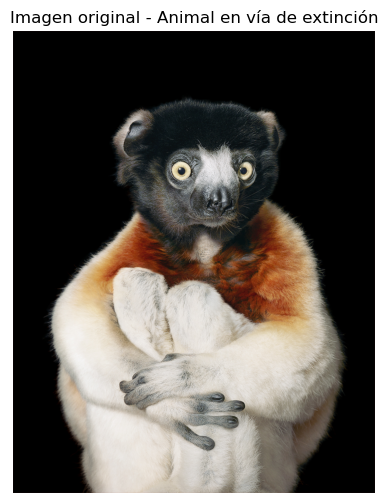

In [73]:
import cv2                  # Para manejo de imágenes
import matplotlib.pyplot as plt
import numpy as np
# Mostrar las imágenes dentro del notebook
%matplotlib inline
imagen = input("Ingrese el numero de la imagen que desea mostrar: ")
# Ruta de la imagen (ajusta el nombre si tu archivo se llama distinto)
image_path = "data/" + imagen + ".jpg"

# cv2.imread carga la imagen en BGR por defecto
img_bgr = cv2.imread(image_path)

# Verificar que la imagen se cargó
print(type(img_bgr), img_bgr.shape)

# Convertir de BGR (OpenCV) a RGB (para visualización correcta)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Mostrar la imagen original en una figura
plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("Imagen original - Animal en vía de extinción")
plt.axis("off")
plt.show()

En esta figura se observa la imagen original en formato RGB de un animal en vía de extinción. La imagen presenta buena iluminación y contraste, lo cual facilitará la aplicación de filtros de suavizado, realce de bordes y las operaciones morfológicas posteriores.

# PASO 2 Filtro de suavizado / desenfoque

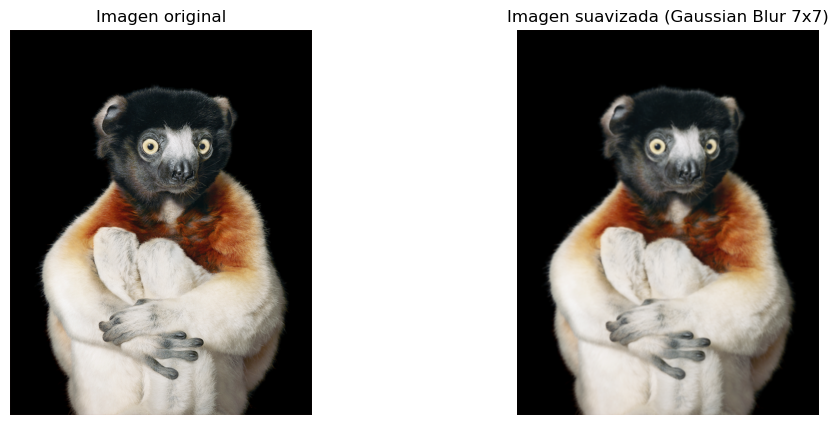

In [74]:
# Filtro de suavizado / desenfoque (Gaussian Blur)
# ksize debe ser impar: (3,3), (5,5), (7,7), etc.
img_blur = cv2.GaussianBlur(img_rgb, (7, 7), 0)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_blur)
plt.title("Imagen suavizada (Gaussian Blur 7x7)")
plt.axis("off")

plt.show()

El filtro Gaussiano reduce el ruido y las variaciones pequeñas de intensidad, suavizando la textura del pelaje y el fondo. Se pierde algo de detalle fino en los bordes, pero la imagen se ve más homogénea.

# Paso 3: Filtro de realce de bordes

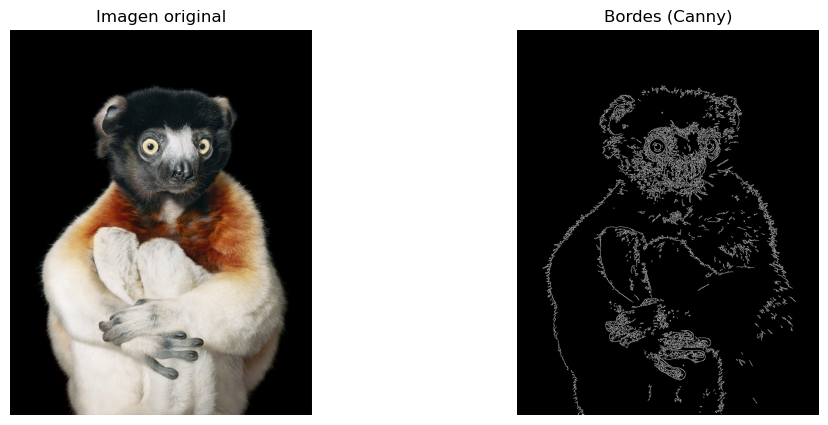

In [75]:
# Convertimos a escala de grises para facilitar la detección de bordes
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Detector de bordes Canny
# Ajusta los umbrales (100, 200) si ves muy pocos o demasiados bordes
edges = cv2.Canny(img_gray, 100, 200)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("Bordes (Canny)")
plt.axis("off")

plt.show()

El detector de bordes Canny resalta los contornos del animal y de los objetos presentes en la escena. Las transiciones bruscas de intensidad (por ejemplo, límites entre el pelaje y el fondo) aparecen como líneas claras. Esto facilita la identificación de formas y estructuras, pero elimina la información de color y textura.

# PUNTO 4 Separar los canales RGB

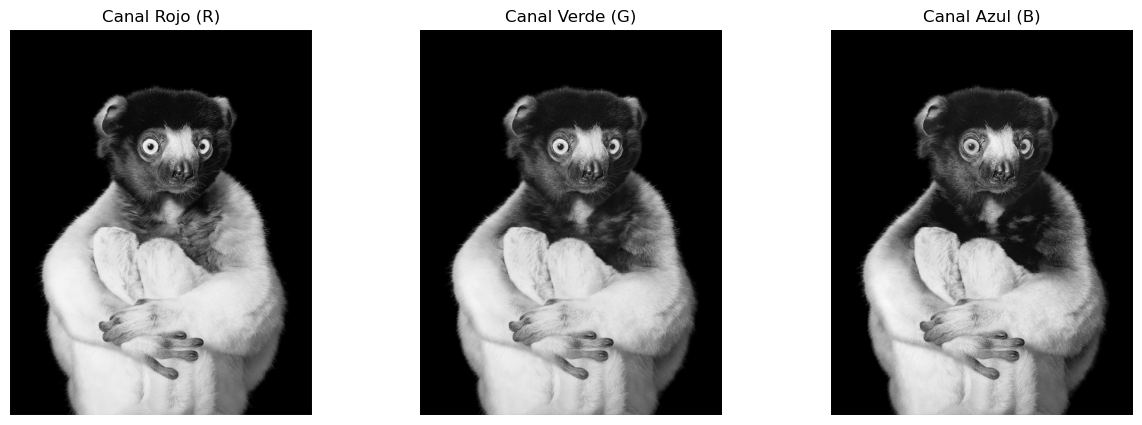

In [76]:
# La imagen img_rgb ya está cargada y en formato RGB
R = img_rgb[:, :, 0]
G = img_rgb[:, :, 1]
B = img_rgb[:, :, 2]

R.shape, G.shape, B.shape
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(R, cmap="gray")
plt.title("Canal Rojo (R)")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(G, cmap="gray")
plt.title("Canal Verde (G)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(B, cmap="gray")
plt.title("Canal Azul (B)")
plt.axis("off")

plt.show()

La separación de los canales permite observar cómo se distribuye la información cromática en la imagen.

El canal R (rojo) suele resaltar zonas cálidas como tonos de piel, tierra o elementos rojizos del animal.

El canal G (verde) generalmente presenta mejor contraste porque el sensor de la cámara tiene más fotodiodos verdes; por eso se observan más detalles en texturas y bordes.

El canal B (azul) tiende a ser más oscuro y ruidoso, especialmente en sombras o zonas poco iluminadas.
Esto permite identificar qué canal aporta más información útil para filtrados, segmentación o análisis posteriores.

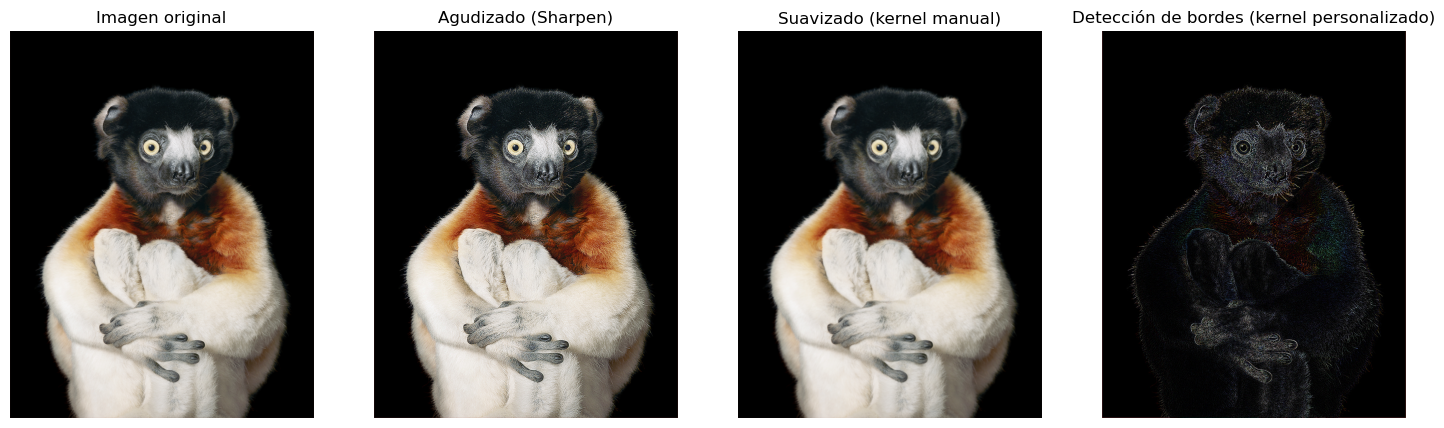

In [77]:
# Creacion de Kernels
# 1. Kernel de agudizado (sharpen)
kernel_sharpen = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# 2. Kernel de suavizado (blur) hecho manualmente
kernel_blur = (1/9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

# 3. Kernel personalizado de detección de bordes
kernel_edge = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Aplicar los kernels con filter2D
img_sharpen = cv2.filter2D(img_rgb, -1, kernel_sharpen)
img_blur_k = cv2.filter2D(img_rgb, -1, kernel_blur)
img_edges_custom = cv2.filter2D(img_rgb, -1, kernel_edge)

plt.figure(figsize=(18, 6))

plt.subplot(1, 4, 1)
plt.imshow(img_rgb)
plt.title("Imagen original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_sharpen)
plt.title("Agudizado (Sharpen)")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_blur_k)
plt.title("Suavizado (kernel manual)")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_edges_custom)
plt.title("Detección de bordes (kernel personalizado)")
plt.axis("off")

plt.show()


El kernel de agudizado incrementa la nitidez realzando transiciones bruscas entre píxeles. Esto hace que los bordes del animal se vean más marcados y definidos.

El kernel de suavizado manual genera un desenfoque uniforme, reduciendo ruido y suavizando texturas. La imagen pierde detalles finos, pero gana homogeneidad.

El kernel personalizado de detección de bordes (similar a Laplaciano) resalta contornos en todas las direcciones. La imagen resultante destaca la estructura del animal y los límites de objetos en la escena.

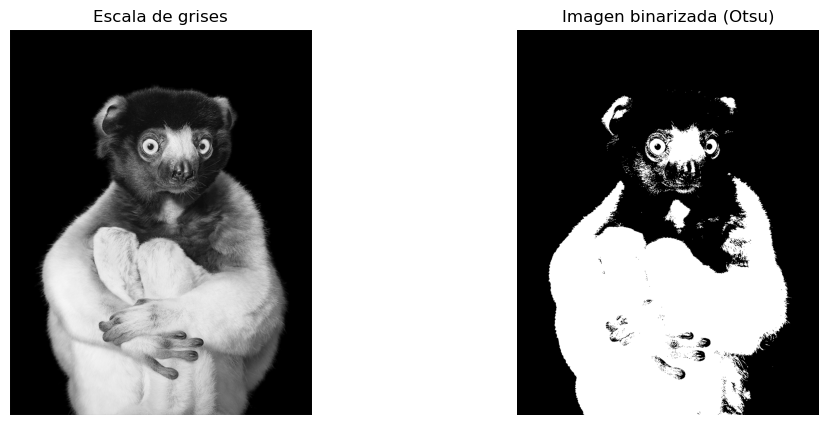

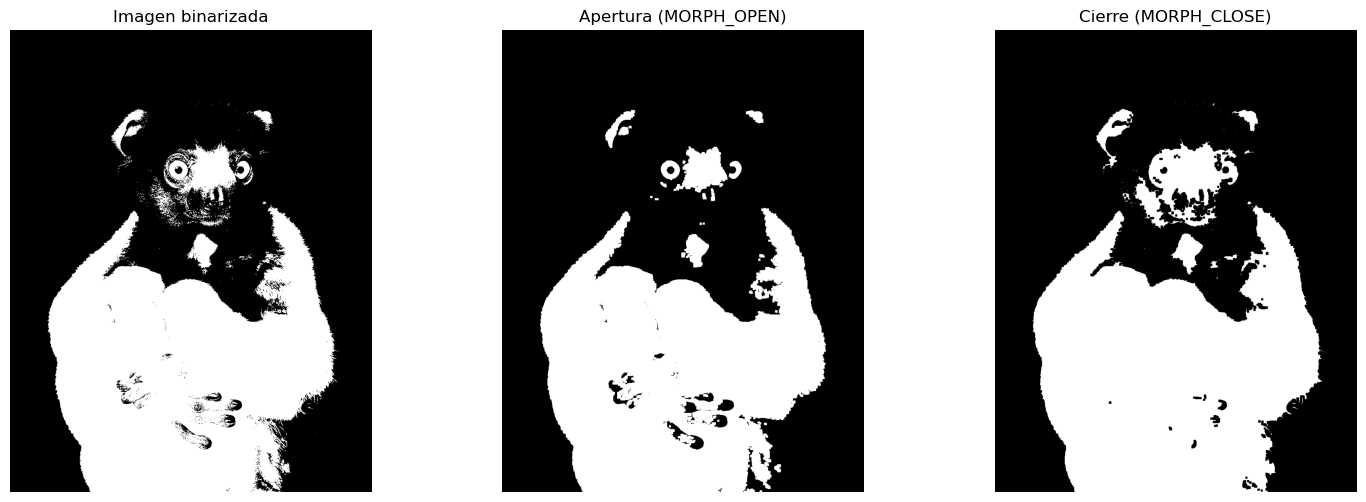

In [78]:
# Asegúrate de tener img_gray (si no, la creamos de nuevo)
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Binarización con Otsu (elige automáticamente el umbral)
_, img_bin = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_gray, cmap="gray")
plt.title("Escala de grises")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binarizada (Otsu)")
plt.axis("off")

plt.show()

# Elemento estructurante (kernel) 5x5
kernel = np.ones((5, 5), np.uint8)
kernel

# Apertura: elimina pequeños objetos blancos
img_open = cv2.morphologyEx(img_bin, cv2.MORPH_OPEN, kernel)

# Cierre: rellena pequeños huecos negros dentro de regiones blancas
img_close = cv2.morphologyEx(img_bin, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img_bin, cmap="gray")
plt.title("Imagen binarizada")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_open, cmap="gray")
plt.title("Apertura (MORPH_OPEN)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_close, cmap="gray")
plt.title("Cierre (MORPH_CLOSE)")
plt.axis("off")

plt.show()

Para este ejercicio se trabajó sobre una versión binarizada de la imagen usando el método de Otsu.

La apertura (MORPH_OPEN) elimina pequeños objetos blancos aislados y suaviza los contornos del animal. Es útil para reducir ruido, pero puede adelgazar ligeramente las estructuras del objeto principal.

El cierre (MORPH_CLOSE) tiende a rellenar pequeños huecos negros dentro de las regiones blancas, cerrando discontinuidades en el contorno y haciendo que las áreas del animal se vean más compactas.
Comparando con la imagen binarizada original, las operaciones morfológicas modifican la forma y continuidad de las regiones, lo que puede ser aprovechado en etapas de segmentación o conteo de objetos.

In [79]:
import os

os.makedirs("gifs", exist_ok=True)

# Asegurarnos de tener las imágenes generadas en pasos anteriores:
# img_rgb, img_blur (o img_blur_k), edges, img_open, img_close

frames = []

# 1. Imagen original
frames.append(img_rgb)

# 2. Suavizado (si usaste img_blur_k, cambia aquí)
frames.append(img_blur)

# 3. Bordes (Canny): convertir a RGB si está en gris
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
frames.append(edges_rgb)

# 4. Apertura morfológica
img_open_rgb = cv2.cvtColor(img_open, cv2.COLOR_GRAY2RGB)
frames.append(img_open_rgb)

# 5. Cierre morfológico
img_close_rgb = cv2.cvtColor(img_close, cv2.COLOR_GRAY2RGB)
frames.append(img_close_rgb)

print("Frames creados:", len(frames))

# Lista de nombres para cada etapa (ajústalos si cambias el orden de frames)
etapas = [
    "Imagen original",
    "Suavizado (blur)",
    "Bordes (Canny)",
    "Morfologia - Apertura",
    "Morfologia - Cierre"
]

frames_annotated = []

for frame, label in zip(frames, etapas):
    # Copiar el frame para no modificar el original
    img = frame.copy()
    
    # Opcional: dibujar una banda semitransparente para mejorar la legibilidad del texto
    overlay = img.copy()
    h, w, _ = img.shape
    cv2.rectangle(overlay, (0, 0), (w, 50), (0, 0, 0), -1)  # banda negra arriba
    alpha = 0.5  # transparencia
    img = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    
    # Agregar el texto
    cv2.putText(
        img,
        label,
        (20, 35),  # posición del texto
        cv2.FONT_HERSHEY_SIMPLEX,
        1.0,              # tamaño de fuente
        (255, 255, 255),  # color blanco
        2,                # grosor
        cv2.LINE_AA
    )
    
    frames_annotated.append(img)

len(frames_annotated)

Frames creados: 5


5

In [80]:
import imageio.v2 as imageio

gif_path = "gifs/procesamiento_imagenes_etapas_"+imagen+".gif"

frames_uint8 = [f.astype(np.uint8) for f in frames_annotated]

imageio.mimsave(
    gif_path,
    frames_uint8,
    duration=1.5,  # segundos por frame (ajusta si lo quieres más lento o rápido)
    loop=0         # 0 = bucle infinito
)

gif_path

'gifs/procesamiento_imagenes_etapas_11.gif'